# Example usage of the package

In [1]:
import reconstructions
import numpy as np
import torch
import matplotlib.pyplot as plt
import torchvision

## Example 1: MNIST + MLP

### Setup network and load training data

In [2]:
# some constants
bs = 64  # batch size
depth = 50  # number of hidden layers
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")  # check for devices
print(f"Device: {device} with {torch.cuda.device_count()} gpus")

# load training/test data
trans = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(), torchvision.transforms.Lambda(lambda x: torch.flatten(x))])
train_data = torchvision.datasets.MNIST("./", train=True, download=True, transform=trans)
val_data = torchvision.datasets.MNIST("./", train=False, transform=trans, download=True)
train_data_loader = torch.utils.data.DataLoader(train_data, batch_size=bs, shuffle=True)
val_data_loader = torch.utils.data.DataLoader(val_data, batch_size=bs, shuffle=False)

# construct a simple MLP (we construct the MLP used in https://arxiv.org/abs/1611.01232)
layer_sizes = [784] * depth + [400, 10]
layers = []
for s1, s2 in zip(layer_sizes[:-2], layer_sizes[1:-1]):
    layers.append(torch.nn.Linear(s1, s2))
    layers.append(torch.nn.Tanh())
layers.append(torch.nn.Linear(layer_sizes[-2], layer_sizes[-1]))
model = torch.nn.Sequential(*layers)


Device: cpu with 0 gpus


### Generate reconstruction model

In [3]:
model_layers, co_model_layers = reconstructions.get_conet_layout(model, batch=(next(iter(train_data))[0]).unsqueeze(0),
                                                                 device=device)
# with (next(iter(train_data))[0]).unsqueeze(0) we select a single sample of the data with size [1, 784] where 784 is flattened sample size

# visualize structure of model vs co_model
#for l, c in zip(model_layers, co_model_layers):
#    print(l)
#    print(c)
#    print("--------------------------------")

### Measure information flow

In [4]:
co_model = reconstructions.ContraNetwork(torch.nn.Sequential(*model_layers), torch.nn.Sequential(*co_model_layers),
                                         device=device)
# with steps we can limit the number of updates. For MLPs around 200 is sufficient
co_model.train(train_data_loader, steps=200, its=1)

C:\Users\yanic\Documents\GitHub\Reconstructor\reconstructions\network_suits.py:155: UserWarning: No GPU available, using CPU instead -> scaler deactivated
  warnings.warn("No GPU available, using CPU instead -> scaler deactivated")



Epoch: 0 / 1

Training done in 49.25951361656189s


Cascade done in 0.8709936141967773s


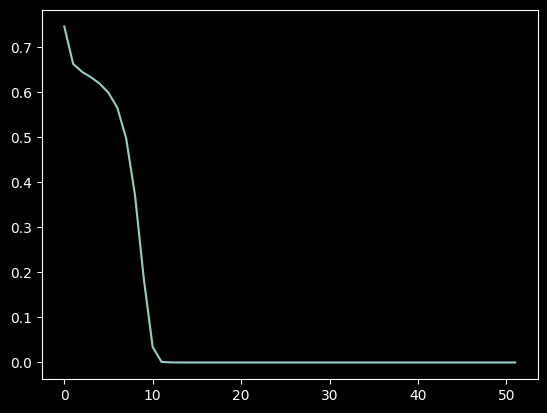

In [5]:
# get entropy profile for this network
cascades = co_model.cascade(next(iter(val_data_loader))[0])

# calculate entropy for each layer
entropies = [reconstructions.gram_neumann_entropy(c).item() for c in cascades]

# plot entropies
plt.plot(entropies)
plt.show()

### Generate entropy plot predicting the empirical measurement in https://arxiv.org/abs/1611.01232

In [6]:
# collect the entropies
VARS = np.arange(0.5, 4.0, 0.5)
entropies = []
for i, var_w in enumerate(VARS):
    print(f"\rStep {i} / {len(VARS)}")
    reconstructions.initialize(torch.nn.Sequential(*model_layers),
                               [var_w, 0.05])  # 0.05 is given in https://arxiv.org/abs/1611.01232

    # reset parameters of co_model_layers
    [[l.reset_parameters() for l in c if hasattr(l, "reset_parameters")] for c in co_model_layers]

    co_model = reconstructions.ContraNetwork(torch.nn.Sequential(*model_layers), torch.nn.Sequential(*co_model_layers),
                                             device=device)
    co_model.train(train_data_loader, steps=200, its=1)
    cascades = co_model.cascade(next(iter(val_data_loader))[0])
    entropies.append([reconstructions.gram_neumann_entropy(c).item() for c in cascades])

Step 0 / 7

Epoch: 0 / 1

Training done in 48.93708825111389s
Cascade done in 0.8585288524627686s
Step 1 / 7

Epoch: 0 / 1

Training done in 48.73704791069031s
Cascade done in 0.8498713970184326s
Step 2 / 7

Epoch: 0 / 1

Training done in 49.467326402664185s
Cascade done in 0.8576123714447021s
Step 3 / 7

Epoch: 0 / 1

Training done in 49.958139181137085s
Cascade done in 0.8607738018035889s
Step 4 / 7

Epoch: 0 / 1

Training done in 49.496522188186646s
Cascade done in 1.0105013847351074s
Step 5 / 7

Epoch: 0 / 1

Training done in 49.08197808265686s
Cascade done in 0.8807415962219238s
Step 6 / 7

Epoch: 0 / 1

Training done in 48.65492057800293s
Cascade done in 0.8449664115905762s


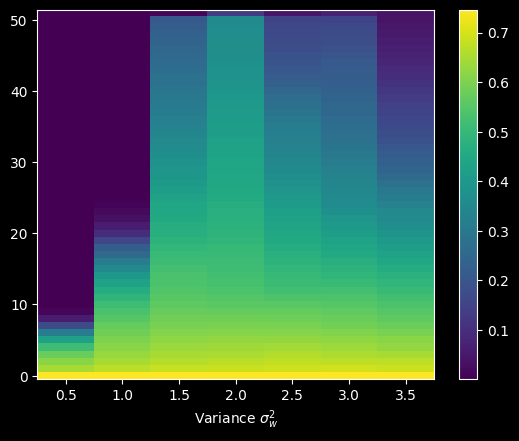

In [7]:
# plot the entropies
plt.imshow(np.array(entropies).swapaxes(0, 1), origin="lower", aspect="auto")
plt.xlabel("Variance $\\sigma_w^2$")
plt.xticks(list(range(len(VARS))), [f"{v:.1f}" for v in VARS])
plt.colorbar()
plt.show()

## Example 2: CIFAR10 + CNN

### Setup network and load training data

In [2]:
# some constants
bs = 64  # batch size
depth = 20  # number of hidden layers
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")  # check for devices
print(f"Device: {device} with {torch.cuda.device_count()} gpus")

# load training/test data
trans = torchvision.transforms.Compose([torchvision.transforms.Grayscale(num_output_channels=1),
                                        torchvision.transforms.ToTensor()])
train_data = torchvision.datasets.CIFAR10("./", train=True, download=True, transform=trans)
val_data = torchvision.datasets.CIFAR10("./", train=False, transform=trans, download=True)
train_data_loader = torch.utils.data.DataLoader(train_data, batch_size=bs, shuffle=True)
val_data_loader = torch.utils.data.DataLoader(val_data, batch_size=bs, shuffle=False)

# construct a simple CNN (we construct the CNN used in https://proceedings.mlr.press/v80/xiao18a/xiao18a.pdf)
c = 128  # number of channels
layers = [
    torch.nn.Conv2d(1, c, kernel_size=(3, 3), stride=1, padding=1), torch.nn.Tanh(),
    torch.nn.Conv2d(c, c, kernel_size=(3, 3), stride=2, padding=1), torch.nn.Tanh(),
    torch.nn.Conv2d(c, c, kernel_size=(3, 3), stride=2, padding=1), torch.nn.Tanh(),
]

for _ in range(depth):
    layers += [torch.nn.Sequential(torch.nn.Conv2d(c, c, kernel_size=(3, 3)), torch.nn.CircularPad2d(1), torch.nn.Tanh())]

layers += [torch.nn.Conv2d(c, c, kernel_size=(3, 3)), torch.nn.Tanh(), torch.nn.AvgPool2d((5, 5)), torch.nn.Flatten()]
layers += [torch.nn.Linear(c, 10, bias=False), torch.nn.Tanh()]

model = torch.nn.Sequential(*layers)


Device: cpu with 0 gpus


### Generate reconstruction model

In [3]:
model_layers, co_model_layers = reconstructions.get_conet_layout(model, batch=(next(iter(train_data))[0]).unsqueeze(0), device=device)
#for l, c in zip(model_layers, co_model_layers):
#    print(l)
#    print(c)
#    print("--------------------------------")

(1, 128, 32, 32) (1, 1, 32, 32)
(1, 128, 16, 16) (1, 128, 32, 32)
(1, 128, 8, 8) (1, 128, 16, 16)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)
(1, 128, 6, 6) (1, 128, 8, 8)


### Measure information flow

In [4]:
co_model = reconstructions.ContraNetwork(torch.nn.Sequential(*model_layers), torch.nn.Sequential(*co_model_layers),
                                         device=device)
# with steps we can limit the number of updates. For MLPs around 200 is sufficient
co_model.train(train_data_loader, its=1)

C:\Users\yanic\Documents\GitHub\Reconstructor\reconstructions\network_suits.py:155: UserWarning: No GPU available, using CPU instead -> scaler deactivated
  warnings.warn("No GPU available, using CPU instead -> scaler deactivated")



Epoch: 0 / 1


RuntimeError: Given transposed=1, weight of size [1, 1, 3, 3], expected input[64, 128, 32, 32] to have 1 channels, but got 128 channels instead

Cascade done in 9.909677267074585s


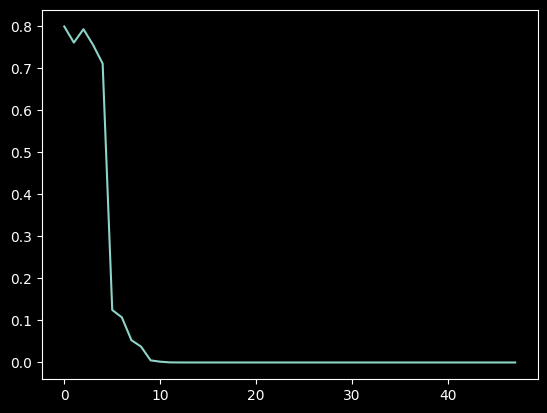

In [12]:
cascades = co_model.cascade(next(iter(val_data_loader))[0])

# calculate entropy for each layer
entropies = [reconstructions.gram_neumann_entropy(c).item() for c in cascades]

# plot entropies
plt.plot(entropies)
plt.show()

### Generate entropy plot predicting the empirical measurement in https://proceedings.mlr.press/v80/xiao18a/xiao18a.pdf

In [ ]:
# collect the entropies
VARS = np.arange(0.2, 2.0, 0.2)
entropies = []
for i, var_w in enumerate(VARS):
    print(f"\rStep {i} / {len(VARS)}")
    reconstructions.initialize(torch.nn.Sequential(*model_layers), [var_w, 2e-5])  # 2e-5 is given in https://proceedings.mlr.press/v80/xiao18a/xiao18a.pdf

    # reset parameters of co_model_layers
    [[l.reset_parameters() for l in c if hasattr(l, "reset_parameters")] for c in co_model_layers]

    co_model = reconstructions.ContraNetwork(torch.nn.Sequential(*model_layers), torch.nn.Sequential(*co_model_layers),
                                             device=device)
    co_model.train(train_data_loader, its=1)
    cascades = co_model.cascade(next(iter(val_data_loader))[0])
    entropies.append([reconstructions.gram_neumann_entropy_stable(c).item() for c in cascades])

Step 0 / 9

Epoch: 0 / 1

Training done in 696.4873774051666s
Cascade done in 9.215253114700317s
Step 1 / 9

Epoch: 0 / 1

Training done in 704.4787001609802s
Cascade done in 10.407219409942627s
Step 2 / 9

Epoch: 0 / 1


In [ ]:
# plot the entropies
plt.imshow(np.array(entropies).swapaxes(0, 1), origin="lower", aspect="auto")
plt.xlabel("Variance $\\sigma_w^2$")
plt.xticks(list(range(len(VARS))), [f"{v:.1f}" for v in VARS])
plt.colorbar()
plt.show()